# From LoRA to QLoRA — Fine-tuning at 4 bits

LoRA solved one half of the fine-tuning memory problem: gradients and optimizer states only have to track the tiny adapter, not the whole model. But "frozen" doesn't mean "free" — the base weights still live on the GPU in bf16 the whole time. For Qwen 2.5 7B that's ~14 GB before activations; for a 70B model, it's 140 GB, out of reach for any single GPU regardless of how clever you are with the optimizer.

**QLoRA** (Dettmers et al., 2023) closes the loop. Quantize the *frozen* base to 4 bits, keep the LoRA adapter in bf16, train as usual. The base footprint drops by roughly `4×`. Suddenly a 70B model fits on a single 48 GB workstation card and a 7B model fits on a 6 GB laptop GPU, with essentially no quality loss reported in the paper.

We'll repeat the SFT setup from class 2 — teaching Qwen 2.5 1.5B-Instruct a structured-output task — but with the base in NF4 instead of bf16. Concretely, every training pair will look like:

- **prompt:** "What's the capital of France?"
- **response:** `{"answer": "Paris", "topic": "geography"}`

This is a clean QLoRA demo because:

- The signal lives in the **response shape** — base Qwen replies in prose; QLoRA will output JSON. Easy to eyeball, easy to *parse* as a hard metric.
- Almost all the class-2 SFT machinery carries over. Only the loading code changes.
- At the end we'll load Qwen 2.5 **7B** in 4 bits and watch it fit in less memory than the **1.5B** in bf16 — the actual point of the technique.

## Part 0 — Setup

In [1]:
# pip install bitsandbytes

In [2]:
# Same boilerplate as last class. New: bitsandbytes for 4-bit weights.
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import gc
import json
import time
import random
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bitsandbytes as bnb
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import (
    LoraConfig, get_peft_model, TaskType,
    prepare_model_for_kbit_training,
)

gpu_id = 7
device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:        {torch.__version__}")
print(f"bitsandbytes:   {bnb.__version__}")
print(f"Device:         {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:            {p.name}")
    print(f"Total memory:   {p.total_memory/1e9:.1f} GB")

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch:        2.10.0+cu128
bitsandbytes:   0.49.2
Device:         cuda:7
GPU:            NVIDIA H200
Total memory:   150.1 GB


In [3]:
def reset_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def report_memory(label):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(f"[{label}] allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB | peak: {peak:.2f} GB")

# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded tokenizer for {MODEL_NAME}")

Loaded tokenizer for Qwen/Qwen2.5-0.5B-Instruct


## Part 1 — Where LoRA still hurts

LoRA's pitch is "you only train ~0.1% of the parameters, so memory drops by ~1000×." That's true for the *parts of memory LoRA touches*: gradients and optimizer states, both of which only have to track the adapter. But there are four big consumers of GPU memory during training, and LoRA only collapses three of them.

### 1.1 Where the bytes go

| Component                 | Full SFT       | LoRA            | QLoRA           |
|---------------------------|----------------|-----------------|-----------------|
| Base weights              | bf16 — full    | bf16 — full     | **NF4 — ¼×**    |
| Adapter weights           | —              | bf16 — small    | bf16 — small    |
| Gradients                 | bf16 — full    | bf16 — small    | bf16 — small    |
| Optimizer states (AdamW)  | fp32 — `2×` full | fp32 — `2×` small | fp32 — `2×` small |

LoRA collapses three columns. The **base weights** column it doesn't touch — and that's the column that dominates as models scale up.

### 1.2 Concrete numbers, Qwen 2.5 7B

| Component                 | Full SFT  | LoRA (r=8) | QLoRA (r=8) |
|---------------------------|-----------|------------|-------------|
| Base weights              | 14 GB     | 14 GB      | **3.5 GB**  |
| Adapter weights           | —         | ~30 MB     | ~30 MB      |
| Gradients                 | 14 GB     | ~30 MB     | ~30 MB      |
| Optimizer states (AdamW)  | ~56 GB    | ~120 MB    | ~120 MB     |
| **Total (no activations)**| **~84 GB**| **~14 GB** | **~3.7 GB** |

Full SFT needs an 80 GB H100. LoRA fits on a 24 GB consumer GPU. QLoRA fits on a 6 GB laptop GPU. The ratios get more dramatic with scale: for 70B, the rows scale linearly to ~840 / ~140 / ~37 GB. The first two are multi-GPU territory; the third runs on a single workstation card.

### 1.3 Why this is even feasible

Two facts about pretrained LLM weights make 4-bit storage workable:

1. The **frozen** base never receives a gradient. We don't need fp16-grade precision for it — we only need *enough* precision to recover decent forward-pass numerics.
2. Pretrained weights are approximately **normally distributed** around zero. There's a 4-bit quantization scheme that exploits this exactly.

That scheme is NF4.

## Part 2 — QLoRA: three tricks stacked

### 2.1 NF4 — 4-bit NormalFloat

Vanilla 4-bit integer quantization (int4) divides the weight range into 16 evenly-spaced buckets. For weights drawn from a roughly normal distribution, that's wasteful — most weights cluster near zero, and most of the buckets get spent on the rarely-visited tails.

NF4 picks the 16 quantization levels at the **quantiles** of a standard normal. Roughly:

$$q_k = \tfrac{1}{2}\!\left[\,\Phi^{-1}\!\left(\tfrac{k}{16}\right) + \Phi^{-1}\!\left(\tfrac{k+1}{16}\right)\,\right], \qquad k = 0, 1, \ldots, 15$$

(rescaled so $q_0 = -1$ and $q_{15} = +1$). Each level then ends up with roughly equal probability mass under a normal distribution. Bits go where the weights actually are.

Three details that matter:

- **Block-wise scaling.** Quantization is per-block (default block size 64). Each block gets its own fp32 scale `s` such that `dequant(q) = s * q`. Storing one scale per 64 weights costs `32/64 = 0.5` bits per weight.
- **Symmetric, zero-preserving.** $q_8 = 0$ exactly. The number `0` is a load-bearing value in neural nets and we don't want it drifting under rounding.
- **Information-theoretic optimality.** For a $\mathcal{N}(0, \sigma^2)$ source, NF4 has the lowest expected reconstruction error among all 4-bit codebooks. The QLoRA paper measures essentially zero accuracy drop on downstream eval.

### 2.2 Double quantization

After NF4, every block of 64 weights stores 256 bits of payload plus one fp32 scale = 32 bits = `0.5` bits/weight of overhead. For a 7B model, those scales add up to ~440 MB of fp32 numbers. So we **quantize the scales themselves**: blocks of 256 fp32 scales get squeezed into 8-bit numbers with their own fp32 super-scale. Saves another ~`0.37` bits per weight, basically free in compute.

### 2.3 Paged optimizers

Optimizer states (`m`, `v` in AdamW) live in fp32. For LoRA they're tiny — but transient activation spikes during backward can still OOM you, especially with long sequences or gradient checkpointing turned on.

Paged optimizers use NVIDIA unified memory: under memory pressure the runtime pages optimizer state out to CPU RAM, pages it back when needed. Much slower if it triggers constantly, but the typical case is a few brief spikes during training that would otherwise crash the run. Cheap insurance, and `bitsandbytes` ships drop-in replacements (`bnb.optim.PagedAdamW8bit`, etc.).

### 2.4 The forward pass, end to end

For each linear layer with weight $W$ in the base:

$$Y \;=\; X\,\big(\,\mathrm{dequant}_{\mathrm{NF4}}(W_q,\, s)\;+\;\tfrac{\alpha}{r}\, A B\,\big)$$

- $W_q$ is the NF4-stored frozen base.
- `dequant` runs **just-in-time**, layer-by-layer, in bf16. The full fp16 weight is never materialized.
- $A, B$ are the LoRA matrices in bf16 — trainable.
- Gradients flow through $A, B$ only. $W_q$ is detached.

The math is identical to vanilla LoRA. The only difference is *where* the base lives between forward passes.

## Part 3 — The SFT dataset

40 hand-authored `(prompt, response)` pairs. Prompts are factual questions; responses are JSON objects with a fixed two-key schema `{"answer": ..., "topic": ...}`. Base Qwen will answer in prose with no schema; the QLoRA-trained adapter should output strictly conforming JSON.

In [4]:
SFT_DATA = [
    # --- geography ---
    {"q": "What's the capital of France?",         "a": '{"answer": "Paris", "topic": "geography"}'},
    {"q": "What's the largest ocean?",             "a": '{"answer": "Pacific Ocean", "topic": "geography"}'},
    {"q": "What's the longest river in the world?", "a": '{"answer": "Nile", "topic": "geography"}'},
    {"q": "What's the smallest country?",          "a": '{"answer": "Vatican City", "topic": "geography"}'},
    {"q": "Which continent is Egypt in?",          "a": '{"answer": "Africa", "topic": "geography"}'},
    {"q": "What's the tallest mountain?",          "a": '{"answer": "Mount Everest", "topic": "geography"}'},
    {"q": "What ocean borders California?",        "a": '{"answer": "Pacific Ocean", "topic": "geography"}'},

    # --- science ---
    {"q": "What's the chemical symbol for gold?",       "a": '{"answer": "Au", "topic": "science"}'},
    {"q": "What's the molecular formula of water?",     "a": '{"answer": "H2O", "topic": "science"}'},
    {"q": "What's the speed of light in km/s?",         "a": '{"answer": "299792", "topic": "science"}'},
    {"q": "How many planets orbit the sun?",            "a": '{"answer": "8", "topic": "science"}'},
    {"q": "What's the boiling point of water in C?",    "a": '{"answer": "100", "topic": "science"}'},
    {"q": "What gas do plants absorb for photosynthesis?", "a": '{"answer": "Carbon dioxide", "topic": "science"}'},
    {"q": "What's the largest planet in the solar system?", "a": '{"answer": "Jupiter", "topic": "science"}'},
    {"q": "What's the hardest natural substance?",      "a": '{"answer": "Diamond", "topic": "science"}'},

    # --- history ---
    {"q": "What year did World War II end?",         "a": '{"answer": "1945", "topic": "history"}'},
    {"q": "Who was the first US president?",         "a": '{"answer": "George Washington", "topic": "history"}'},
    {"q": "What year did humans first land on the moon?", "a": '{"answer": "1969", "topic": "history"}'},
    {"q": "Who wrote the Communist Manifesto?",      "a": '{"answer": "Karl Marx", "topic": "history"}'},
    {"q": "What dissolved in 1991?",                 "a": '{"answer": "The Soviet Union", "topic": "history"}'},
    {"q": "Who reached the Americas in 1492?",       "a": '{"answer": "Christopher Columbus", "topic": "history"}'},

    # --- arts ---
    {"q": "Who painted the Mona Lisa?",              "a": '{"answer": "Leonardo da Vinci", "topic": "arts"}'},
    {"q": "Who wrote Hamlet?",                       "a": '{"answer": "William Shakespeare", "topic": "arts"}'},
    {"q": "Who composed the Ninth Symphony?",        "a": '{"answer": "Ludwig van Beethoven", "topic": "arts"}'},
    {"q": "Who wrote Pride and Prejudice?",          "a": '{"answer": "Jane Austen", "topic": "arts"}'},
    {"q": "Who painted The Starry Night?",           "a": '{"answer": "Vincent van Gogh", "topic": "arts"}'},
    {"q": "Who wrote 1984?",                         "a": '{"answer": "George Orwell", "topic": "arts"}'},

    # --- math ---
    {"q": "What's 7 times 8?",                       "a": '{"answer": "56", "topic": "math"}'},
    {"q": "What's the square root of 144?",          "a": '{"answer": "12", "topic": "math"}'},
    {"q": "What's 2 to the power of 8?",             "a": '{"answer": "256", "topic": "math"}'},
    {"q": "What's 100 divided by 4?",                "a": '{"answer": "25", "topic": "math"}'},
    {"q": "What's pi to two decimal places?",        "a": '{"answer": "3.14", "topic": "math"}'},
    {"q": "How many sides does a hexagon have?",     "a": '{"answer": "6", "topic": "math"}'},

    # --- language ---
    {"q": "What language is spoken in Brazil?",      "a": '{"answer": "Portuguese", "topic": "language"}'},
    {"q": "What language is spoken in Austria?",     "a": '{"answer": "German", "topic": "language"}'},
    {"q": "How do you say hello in Spanish?",        "a": '{"answer": "Hola", "topic": "language"}'},

    # --- tech ---
    {"q": "What does HTTP stand for?",               "a": '{"answer": "HyperText Transfer Protocol", "topic": "tech"}'},
    {"q": "What does CPU stand for?",                "a": '{"answer": "Central Processing Unit", "topic": "tech"}'},
    {"q": "Who founded Microsoft?",                  "a": '{"answer": "Bill Gates", "topic": "tech"}'},
    {"q": "What does URL stand for?",                "a": '{"answer": "Uniform Resource Locator", "topic": "tech"}'},
]

print(f"Training examples: {len(SFT_DATA)}")

Training examples: 40


In [5]:
# Held-out set — same schema, unseen prompts.
SFT_VAL = [
    {"q": "What's the capital of Japan?",            "a": '{"answer": "Tokyo", "topic": "geography"}'},
    {"q": "What's the smallest planet?",             "a": '{"answer": "Mercury", "topic": "science"}'},
    {"q": "Who wrote Don Quixote?",                  "a": '{"answer": "Miguel de Cervantes", "topic": "arts"}'},
    {"q": "What's 9 times 12?",                      "a": '{"answer": "108", "topic": "math"}'},
    {"q": "What language is the official language of Egypt?", "a": '{"answer": "Arabic", "topic": "language"}'},
    {"q": "What does GPU stand for?",                "a": '{"answer": "Graphics Processing Unit", "topic": "tech"}'},
    {"q": "Who painted Guernica?",                   "a": '{"answer": "Pablo Picasso", "topic": "arts"}'},
    {"q": "What year did the Berlin Wall fall?",     "a": '{"answer": "1989", "topic": "history"}'},
    {"q": "What's the chemical symbol for iron?",    "a": '{"answer": "Fe", "topic": "science"}'},
    {"q": "What's the largest hot desert on Earth?", "a": '{"answer": "Sahara", "topic": "geography"}'},
]

print(f"Held-out examples: {len(SFT_VAL)}")

Held-out examples: 10


## Part 4 — Loading the model in 4 bits

### 4.1 `BitsAndBytesConfig`

The config object bundles all three QLoRA tricks plus a few practical knobs:

- `load_in_4bit=True` — turn on 4-bit loading for linear layers.
- `bnb_4bit_quant_type="nf4"` — use NF4 (vs `"fp4"`, the older 4-bit float format).
- `bnb_4bit_use_double_quant=True` — double quantization (Section 2.2).
- `bnb_4bit_compute_dtype=torch.bfloat16` — dequantize to bf16 for the matmul. This is *not* the storage dtype; it's what NF4 gets cast to right before the multiply. You want bf16 here for numerical headroom; fp16 sometimes underflows on the rare large activations.

Also note: when loading in 4-bit you can't use `.to(device)` after the fact — you have to pass `device_map` to `from_pretrained` and let `bitsandbytes` place the quantized weights directly.

In [6]:
def hard_reset():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

hard_reset()

def fresh_4bit_model(model_name=MODEL_NAME):
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_cfg,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
    )

    model.eval()
    return model


hard_reset()
nf4_model = fresh_4bit_model()
report_memory(f"{MODEL_NAME} in NF4 + DQ")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 600.14it/s]


[Qwen/Qwen2.5-0.5B-Instruct in NF4 + DQ] allocated: 0.00 GB | reserved: 0.00 GB | peak: 0.00 GB


### 4.2 Side-by-side memory: bf16 vs NF4

Drop the 4-bit model, load the same checkpoint in bf16, measure the peak. The ratio is the cleanest sanity check that quantization actually fired.

In [7]:
del nf4_model
hard_reset()

bf16_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16
).to(device)
report_memory(f"{MODEL_NAME} in bf16")

del bf16_model
hard_reset()

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5805.51it/s]


[Qwen/Qwen2.5-0.5B-Instruct in bf16] allocated: 0.00 GB | reserved: 0.00 GB | peak: 0.00 GB


**Read those numbers.** The 1.5B model is small enough that absolute savings look modest (~3 GB → ~0.9 GB on most setups). The interesting quantity is the *ratio*: ≈ `4×` reduction, exactly as predicted by 16 bits / 4 bits. The same code on a 7B model would save ~10 GB; on a 70B model, ~100 GB. We'll verify the 7B case at the end of the notebook.

### 4.3 Wrapping with LoRA

Three steps:

1. Reload the model in 4-bit (we deleted it for the comparison above).
2. Run `prepare_model_for_kbit_training` — it casts layer norms and the embedding output to fp32 for numerical stability, disables KV caching during training, and sets up gradient-checkpointing hooks if asked. Skipping this step usually trains, but loss is noisier.
3. `get_peft_model` to attach the LoRA adapter, exactly the same call as class 2.

In [8]:
reset_memory()
model = fresh_4bit_model()
model = prepare_model_for_kbit_training(model)

cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.0,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, cfg)
model.print_trainable_parameters()
report_memory(f"{MODEL_NAME} QLoRA (NF4 + LoRA r=8)")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 568.75it/s]


trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826
[Qwen/Qwen2.5-0.5B-Instruct QLoRA (NF4 + LoRA r=8)] allocated: 0.00 GB | reserved: 0.00 GB | peak: 0.00 GB


**Read those numbers.** `print_trainable_parameters` should report ~0.5–1% of the model's parameters as trainable — that's the LoRA `A` and `B` matrices on `q_proj/k_proj/v_proj/o_proj/gate_proj/up_proj/down_proj`. The rest of the model is the frozen NF4 base. Peak memory should be only marginally higher than the bare NF4 load: the adapter is small.

## Part 5 — Training the QLoRA adapter

The training loop is structurally identical to SFT-LoRA from class 2. Two QLoRA-specific changes:

- The model is already loaded in 4-bit and wrapped with PEFT — we don't re-instantiate inside `train_qlora`, we just train the existing `model`.
- The optimizer is `bnb.optim.PagedAdamW8bit`. Same convergence as fp32 AdamW (we'll verify the loss curve), with 8-bit optimizer states + paged memory for transient spikes.

### 5.1 Tokenization

Same `tokenize_chat` and `collate` as class 2.

In [9]:
def tokenize_chat(example, tokenizer, max_len=512):
    """Render chat template, tokenize, mask prompt with -100 (same as class 2)."""
    user_msg = [{"role": "user", "content": example["q"]}]
    full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

    prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
    full_text = tokenizer.apply_chat_template(
        full_msg, add_generation_prompt=False, tokenize=False
    )

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids   = tokenizer(full_text,   add_special_tokens=False).input_ids[:max_len]

    labels = list(full_ids)
    for i in range(min(len(prompt_ids), len(full_ids))):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


def collate(batch, pad_id):
    """Same padding collator as class 2."""
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"]    + [-100]   * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids":      torch.tensor(ids).to(device),
        "labels":         torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }


train_examples = [tokenize_chat(ex, tokenizer) for ex in SFT_DATA]
val_examples   = [tokenize_chat(ex, tokenizer) for ex in SFT_VAL]
print(f"Tokenized: {len(train_examples)} train | {len(val_examples)} val")

Tokenized: 40 train | 10 val


### 5.2 Sanity check — is the gradient actually flowing through LoRA?

Quick check: a single forward+backward should produce non-zero gradients on the LoRA `B` matrices (they're initialized to zero, so any gradient there means the loss noticed them) and **no** gradient on the quantized base.

In [10]:
# Single-step gradient check.
model.train()
batch = collate(train_examples[:2], tokenizer.pad_token_id)
out = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    labels=batch["labels"],
)
out.loss.backward()

trainable_grads = [
    p.grad.abs().mean().item()
    for p in model.parameters()
    if p.requires_grad and p.grad is not None
]
frozen_with_grad = sum(
    1 for p in model.parameters() if not p.requires_grad and p.grad is not None
)

print(f"loss at first step:        {out.loss.item():.4f}")
print(f"trainable params w/ grad:  {len(trainable_grads)}")
print(f"mean |grad| over LoRA:     {sum(trainable_grads)/len(trainable_grads):.2e}")
print(f"frozen params w/ grad:     {frozen_with_grad}   (expected 0)")

# Reset for the real training run below.
for p in model.parameters():
    if p.grad is not None:
        p.grad = None

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


loss at first step:        3.1842
trainable params w/ grad:  336
mean |grad| over LoRA:     8.81e-03
frozen params w/ grad:     0   (expected 0)


**Read those numbers.** Loss is finite (~few units), the LoRA params have non-zero gradients, and *no* frozen base param has a gradient. The base is genuinely detached behind the NF4 storage layer — gradients only travel through the bf16 adapter. That's what makes training cheap.

### 5.3 The training loop

In [11]:
def train_qlora(model, examples, lr=5e-5, epochs=4, batch_size=2, seed=0, verbose=True):
    """One QLoRA SFT training run on an already-prepared `model`."""
    reset_memory()
    random.seed(seed)
    torch.manual_seed(seed)

    opt = bnb.optim.PagedAdamW8bit(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=0.0,
    )

    history = {"loss": []}
    model.train()
    for epoch in range(epochs):
        random.shuffle(examples)
        for i in range(0, len(examples), batch_size):
            batch = collate(examples[i : i + batch_size], tokenizer.pad_token_id)
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            out.loss.backward()
            opt.step()
            opt.zero_grad()
            history["loss"].append(out.loss.item())

        if verbose:
            print(f"  epoch {epoch+1}/{epochs} | loss {history['loss'][-1]:.3f}")

    if verbose:
        report_memory("QLoRA training")
    return history


print("\n========== Training QLoRA (r=8, NF4 + DQ + paged AdamW) ==========")
qlora_history = train_qlora(model, train_examples, lr=5e-5, epochs=4, batch_size=2)


========== Training QLoRA (r=8, NF4 + DQ + paged AdamW) ==========
  epoch 1/4 | loss 0.324
  epoch 2/4 | loss 0.036
  epoch 3/4 | loss 0.017
  epoch 4/4 | loss 0.018
[QLoRA training] allocated: 0.00 GB | reserved: 0.00 GB | peak: 0.00 GB


### 5.4 Loss curve

Should drop steeply early — the base model has near-zero probability mass on a strict JSON schema, so almost any gradient step reduces loss a lot — then plateau as the adapter saturates the small dataset.

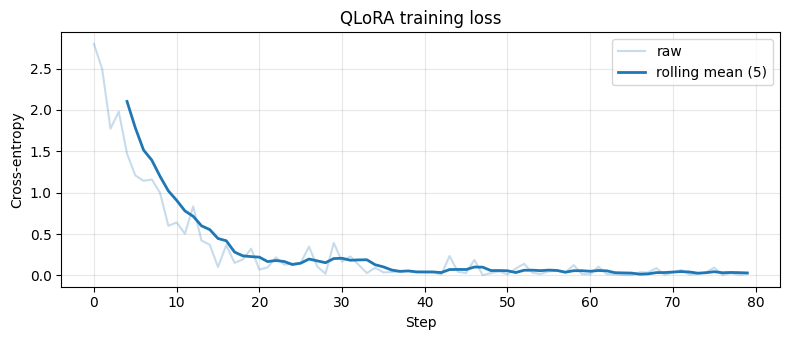

In [ ]:
window = 5
plt.figure(figsize=(8, 3.5))
loss_smooth = pd.Series(qlora_history["loss"]).rolling(window).mean()
plt.plot(qlora_history["loss"], color="tab:blue", alpha=0.25, label="raw")
plt.plot(loss_smooth, color="tab:blue", lw=2, label=f"rolling mean ({window})")
plt.xlabel("Step")
plt.ylabel("Cross-entropy")
plt.title("QLoRA training loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 6 — Did it actually learn the schema?

Three evaluations, ordered from cheapest to most concrete:

1. **Generation comparison** — sample from base vs QLoRA on held-out prompts. Eyeball whether the JSON appears.
2. **JSON parse rate** — hard metric. Of the held-out outputs, how many parse to a dict containing both expected keys?
3. **Scaling demo** — load Qwen 2.5 **7B** in 4 bits and watch it fit in less memory than the 1.5B did in bf16.

### 6.1 Generation comparison

Same `disable_adapter` trick from class 2 to peek at base behavior. One subtlety: with the adapter off, we're looking at the **NF4-quantized** base, not the original bf16 base. That's the apples-to-apples comparison for "what did the adapter add" — both rows below run on identical NF4 weights, only the adapter is toggled.

In [13]:
def generate(model, prompt, max_new_tokens=80, use_adapter=True):
    model.eval()
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True,
    ).to(device)
    if use_adapter:
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    else:
        with torch.no_grad(), model.disable_adapter():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()


PROBE = [
    "What's the capital of Australia?",
    "Who wrote Romeo and Juliet?",
    "What's the chemical symbol for silver?",
    "How many continents are there?",
    "What language is spoken in the Netherlands?",
    "Who painted The Persistence of Memory?",
]

for p in PROBE:
    base_out  = generate(model, p, use_adapter=False)
    qlora_out = generate(model, p, use_adapter=True)
    print("-" * 80)
    print(f"PROMPT: {p}")
    print(f"BASE:   {base_out[:160]}")
    print(f"QLORA:  {qlora_out[:160]}")
print("-" * 80)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--------------------------------------------------------------------------------
PROMPT: What's the capital of Australia?
BASE:   The capital of Australia is Canberra. It is located in the northeastern part of the country and serves as the administrative center for the entire country. Canb
QLORA:  {"answer": " Canberra", "topic": "geography"}
--------------------------------------------------------------------------------
PROMPT: Who wrote Romeo and Juliet?
BASE:   I'm sorry for the confusion, but I am not Qwen, an artificial intelligence created by Alibaba Cloud. I do not have access to information about specific authors 
QLORA:  {"answer": "William Shakespeare", "topic": "arts"}
--------------------------------------------------------------------------------
PROMPT: What's the chemical symbol for silver?
BASE:   The chemical symbol for silver is Ag.
QLORA:  {"answer": "Ag", "topic": "science"}
--------------------------------------------------------------------------------
PROMPT: Ho

### 6.2 JSON parse rate

The eyeball check is reassuring; a hard metric is better. Define success as: the output parses as JSON, *and* it has the two required keys.

In [14]:
def parses_to_schema(text):
    """Output must be valid JSON dict with both 'answer' and 'topic' keys."""
    try:
        obj = json.loads(text)
    except (json.JSONDecodeError, TypeError):
        return False
    return isinstance(obj, dict) and "answer" in obj and "topic" in obj


base_ok, qlora_ok = 0, 0
for ex in SFT_VAL:
    base_out  = generate(model, ex["q"], use_adapter=False)
    qlora_out = generate(model, ex["q"], use_adapter=True)
    if parses_to_schema(base_out):  base_ok  += 1
    if parses_to_schema(qlora_out): qlora_ok += 1

n = len(SFT_VAL)
print(f"Held-out JSON parse rate (base):   {base_ok}/{n}  ({100*base_ok/n:.0f}%)")
print(f"Held-out JSON parse rate (QLoRA):  {qlora_ok}/{n}  ({100*qlora_ok/n:.0f}%)")

Held-out JSON parse rate (base):   0/10  (0%)
Held-out JSON parse rate (QLoRA):  10/10  (100%)


# Tarea en clase

Aplica QLoRA a una **tarea SFT distinta a la de hoy**, sobre Qwen 2.5 1.5B-Instruct (o el modelo más grande que tu GPU permita cargar en 4 bits — intenta 7B).

1. **Define la tarea.** Crea ~40 pares `(prompt, respuesta)` con un formato de salida bien definido distinto al JSON `{answer, topic}` de hoy: extracción de entidades, traducción español↔inglés, generación de SQL desde lenguaje natural, conversión de fecha a ISO 8601, etc.
2. **Entrena tres configuraciones** sobre tu dataset, manteniendo `r=8` y el resto de hiperparámetros igual:
   - QLoRA (NF4 + double quant) con `bnb.optim.PagedAdamW8bit`
   - QLoRA (NF4 **sin** double quant) con `bnb.optim.PagedAdamW8bit`
   - LoRA en bf16 (sin cuantización) con `torch.optim.AdamW` — la línea base de la clase 2
3. **Reporta:**
   - Pico de memoria GPU para cada configuración (separa el de carga del modelo y el de entrenamiento).
   - Curvas de loss para las tres en una sola gráfica.
   - Una métrica dura de éxito en held-out apropiada para tu formato (parse rate, exact match, BLEU…) sobre 10 ejemplos.
   - 3 generaciones de ejemplo de cada configuración sobre prompts no vistos.
   - Una conclusión: ¿la cuantización a 4 bits costó algo en *calidad*? ¿Cuánta memoria ahorraste **en proporción**? ¿Cuándo elegirías QLoRA sobre LoRA, y cuándo no?